In [1]:
import kagglehub
import os
import pandas as pd

# 1. Download the dataset (It will likely use the cached version if you already ran it)
path = kagglehub.dataset_download("ascanipek/eyepacs-aptos-messidor-diabetic-retinopathy")

print(f"--- Dataset is at: {path} ---")

# 2. Look inside the main folder
print("\n[Files in main folder]:")
files = os.listdir(path)
print(files)

# 3. Check for subfolders or CSVs
image_dir = None
csv_file = None

# Logic to auto-detect the structure
for f in files:
    if f.endswith(".csv"):
        csv_file = os.path.join(path, f)
        print(f"\nFOUND CSV: {csv_file}")
    elif os.path.isdir(os.path.join(path, f)):
        print(f"\nFOUND FOLDER: {f}")
        # Check if this folder contains images or class subfolders
        subfiles = os.listdir(os.path.join(path, f))[:5]
        print(f"  -> Inside '{f}': {subfiles}")
        image_dir = os.path.join(path, f)

# 4. If no CSV found, we might need to create one from folder names
if csv_file is None:
    print("\n[INFO] No CSV found. We might need to create labels from folder names (0, 1, 2, 3, 4).")

--- Dataset is at: /kaggle/input/datasets/ascanipek/eyepacs-aptos-messidor-diabetic-retinopathy ---

[Files in main folder]:
['dr_unified_v2', 'augmented_resized_V2']

FOUND FOLDER: dr_unified_v2
  -> Inside 'dr_unified_v2': ['dr_unified_v2']

FOUND FOLDER: augmented_resized_V2
  -> Inside 'augmented_resized_V2': ['val', 'test', 'train']

[INFO] No CSV found. We might need to create labels from folder names (0, 1, 2, 3, 4).


In [4]:
# --- CELL 1: SETUP ---
# Install necessary libraries for modern models and data loading
!pip install -q timm albumentations kagglehub

import os
import cv2
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler # Mixed Precision for speed
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import cohen_kappa_score, accuracy_score
import albumentations as A
from albumentations.pytorch import ToTensorV2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import timm
import kagglehub
from tqdm.notebook import tqdm # Progress bar

# Set deterministic seed for reproducibility (Crucial for papers)
def seed_everything(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

seed_everything()
print("Setup Complete. Libraries Installed.")

Setup Complete. Libraries Installed.


In [6]:
# --- CELL 2: CONFIGURATION ---
class Config:
    seed = 42
    img_size = 224        # 224 is standard for ConvNeXt/Swin. Increase to 384 for final training.
    num_classes = 5
    batch_size = 32       # Lower to 16 if you get "CUDA Out of Memory"
    epochs = 10           # For testing. Use 30-50 for final paper.
    n_folds = 5
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # Model Choice: Change this to 'swin', 'effnet', or 'convnext'
    model_name = 'convnext' 
    
    # DOWNLOAD DATASET (Runs only if not already present)
    base_path = kagglehub.dataset_download("ascanipek/eyepacs-aptos-messidor-diabetic-retinopathy")
    
    # Dynamic Path Finding
    train_dir = os.path.join(base_path, "augmented_resized_V2", "train")
    csv_save_path = "dataset_map.csv"

print(f"Configuration Loaded. \nData Path: {Config.train_dir}")

Configuration Loaded. 
Data Path: /kaggle/input/datasets/ascanipek/eyepacs-aptos-messidor-diabetic-retinopathy/augmented_resized_V2/train


In [7]:
# --- CELL 3: DATA MAPPING ---
def create_dataset_map():
    if os.path.exists(Config.csv_save_path):
        print(f"Loading existing map from {Config.csv_save_path}")
        return pd.read_csv(Config.csv_save_path)

    print("Scanning folders to build dataset map...")
    data = []
    
    # Expected folder names in this dataset are usually numbers or class names
    try:
        classes = sorted([d for d in os.listdir(Config.train_dir) if os.path.isdir(os.path.join(Config.train_dir, d))])
    except FileNotFoundError:
        print("ERROR: Training folder not found. Check Config path.")
        return pd.DataFrame()

    print(f"Found classes: {classes}")

    for class_name in classes:
        class_path = os.path.join(Config.train_dir, class_name)
        
        # Robust label assignment
        try:
            label = int(class_name)
        except ValueError:
            # Map text names to numbers if necessary
            mapping = {'No_DR': 0, 'Mild': 1, 'Moderate': 2, 'Severe': 3, 'Proliferate_DR': 4}
            label = mapping.get(class_name, -1)
        
        if label == -1: continue

        # Gather images
        files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        for f in files:
            data.append({'image_path': os.path.join(class_path, f), 'label': label})
    
    df = pd.DataFrame(data)
    
    # Create Stratified Folds
    skf = StratifiedKFold(n_splits=Config.n_folds, shuffle=True, random_state=Config.seed)
    df['fold'] = -1
    for fold, (_, val_idx) in enumerate(skf.split(df, df['label'])):
        df.loc[val_idx, 'fold'] = fold
        
    df.to_csv(Config.csv_save_path, index=False)
    print(f"Map created with {len(df)} images.")
    return df

# Execute immediately to check
df = create_dataset_map()
print(df.head())

Scanning folders to build dataset map...
Found classes: ['0', '1', '2', '3', '4']
Map created with 115241 images.
                                          image_path  label  fold
0  /kaggle/input/datasets/ascanipek/eyepacs-aptos...      0     1
1  /kaggle/input/datasets/ascanipek/eyepacs-aptos...      0     0
2  /kaggle/input/datasets/ascanipek/eyepacs-aptos...      0     3
3  /kaggle/input/datasets/ascanipek/eyepacs-aptos...      0     4
4  /kaggle/input/datasets/ascanipek/eyepacs-aptos...      0     0


In [8]:
# --- CELL 4: DATASET & TRANSFORMS ---
class DRDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row['image_path']
        label = row['label']

        image = cv2.imread(img_path)
        if image is None:
            image = np.zeros((Config.img_size, Config.img_size, 3), dtype=np.uint8)
        else:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']

        return image, torch.tensor(label, dtype=torch.long)

def get_transforms(data='train'):
    if data == 'train':
        return A.Compose([
            A.Resize(Config.img_size, Config.img_size),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomRotate90(p=0.5),
            A.CLAHE(clip_limit=4.0, p=0.7), # Key for medical imaging
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2(),
        ])
    else:
        return A.Compose([
            A.Resize(Config.img_size, Config.img_size),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2(),
        ])
print("Dataset pipeline ready.")

Dataset pipeline ready.


In [9]:
# --- CELL 5: MODEL ARCHITECTURE ---
class DRModel(nn.Module):
    def __init__(self, model_name, num_classes=5, pretrained=True):
        super(DRModel, self).__init__()
        
        # Select architecture based on config
        if model_name == 'convnext':
            self.backbone = timm.create_model('convnext_tiny', pretrained=pretrained, num_classes=0)
        elif model_name == 'swin':
            self.backbone = timm.create_model('swin_tiny_patch4_window7_224', pretrained=pretrained, num_classes=0)
        elif model_name == 'effnet':
            self.backbone = timm.create_model('tf_efficientnet_b4', pretrained=pretrained, num_classes=0)
        
        self.n_features = self.backbone.num_features
        
        # Head with Dropout for Uncertainty (Monte Carlo Dropout compatible)
        self.drop = nn.Dropout(p=0.3)
        self.fc = nn.Linear(self.n_features, num_classes)

    def forward(self, x):
        features = self.backbone(x)
        x = self.drop(features)
        output = self.fc(x)
        return output

print("Model architecture defined.")

Model architecture defined.


In [10]:
# --- CELL 6: LOSS & UTILS ---
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        CE_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-CE_loss)
        F_loss = self.alpha * (1-pt)**self.gamma * CE_loss
        if self.reduction == 'mean': return torch.mean(F_loss)
        return F_loss

def train_one_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    running_loss = 0.0
    
    pbar = tqdm(loader, desc="Training")
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        with autocast(): # Mixed Precision
            outputs = model(images)
            loss = criterion(outputs, labels)
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item()
        pbar.set_postfix(loss=running_loss/len(loader))
        
    return running_loss / len(loader)

@torch.no_grad()
def valid_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    preds_all = []
    labels_all = []
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        running_loss += loss.item()
        preds_all.append(outputs.softmax(1).cpu().numpy())
        labels_all.append(labels.cpu().numpy())
        
    preds_all = np.concatenate(preds_all)
    labels_all = np.concatenate(labels_all)
    
    # Calculate QWK (Quadratic Weighted Kappa) - The Main Competition Metric
    predictions = np.argmax(preds_all, axis=1)
    qwk = cohen_kappa_score(labels_all, predictions, weights='quadratic')
    acc = accuracy_score(labels_all, predictions)
    
    return running_loss / len(loader), qwk, acc

print("Training utilities ready.")

Training utilities ready.


In [11]:
# --- CELL 7: START TRAINING ---
def run_training():
    # Load Data
    df = pd.read_csv(Config.csv_save_path)
    
    # Filter for Fold 0 (Train on 1,2,3,4 | Validate on 0)
    train_df = df[df['fold'] != 0].reset_index(drop=True)
    valid_df = df[df['fold'] == 0].reset_index(drop=True)
    
    # Datasets
    train_ds = DRDataset(train_df, transform=get_transforms('train'))
    valid_ds = DRDataset(valid_df, transform=get_transforms('valid'))
    
    train_loader = DataLoader(train_ds, batch_size=Config.batch_size, shuffle=True, num_workers=2)
    valid_loader = DataLoader(valid_ds, batch_size=Config.batch_size, shuffle=False, num_workers=2)
    
    # Model Setup
    model = DRModel(Config.model_name, num_classes=Config.num_classes).to(Config.device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
    criterion = FocalLoss(gamma=2.0)
    scaler = GradScaler()
    
    best_qwk = 0.0
    
    print(f"Starting Training: {Config.model_name} | Fold 0")
    
    for epoch in range(Config.epochs):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, scaler, Config.device)
        val_loss, qwk, acc = valid_one_epoch(model, valid_loader, criterion, Config.device)
        
        print(f"Epoch {epoch+1}/{Config.epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | QWK: {qwk:.4f} | Acc: {acc:.4f}")
        
        # Save Best Model
        if qwk > best_qwk:
            best_qwk = qwk
            torch.save(model.state_dict(), f"{Config.model_name}_fold0_best.pth")
            print(f"  >>> Model Saved (QWK: {qwk:.4f})")
            
# Run it!
run_training()

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Starting Training: convnext | Fold 0


/tmp/ipykernel_55/776050943.py:21: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Training:   0%|          | 0/2881 [00:00<?, ?it/s]

/tmp/ipykernel_55/1505276232.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # Mixed Precision


...

/tmp/ipykernel_55/1505276232.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # Mixed Precision


Epoch 9/10 | Train Loss: 0.1455 | Val Loss: 0.1802 | QWK: 0.8696 | Acc: 0.8346


Training:   0%|          | 0/2881 [00:00<?, ?it/s]

/tmp/ipykernel_55/1505276232.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # Mixed Precision


Epoch 10/10 | Train Loss: 0.1364 | Val Loss: 0.1878 | QWK: 0.8745 | Acc: 0.8381
  >>> Model Saved (QWK: 0.8745)


[INFO] Initializing Complete Research Evaluation Protocol...
[INFO] Loading weights: convnext_fold0_best.pth
[INFO] Running inference on 23049 validation samples...


Inference:   0%|          | 0/721 [00:00<?, ?it/s]


1. ROC-AUC PERFORMANCE
Class 0 (No DR       ) AUC: 0.9613
Class 1 (Mild        ) AUC: 0.9347
Class 2 (Moderate    ) AUC: 0.9225
Class 3 (Severe      ) AUC: 0.9935
Class 4 (Proliferative) AUC: 0.9911


/tmp/ipykernel_55/1623159190.py:130: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k--" (-> linestyle='--'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], 'k--', lw=2, linestyle='--')


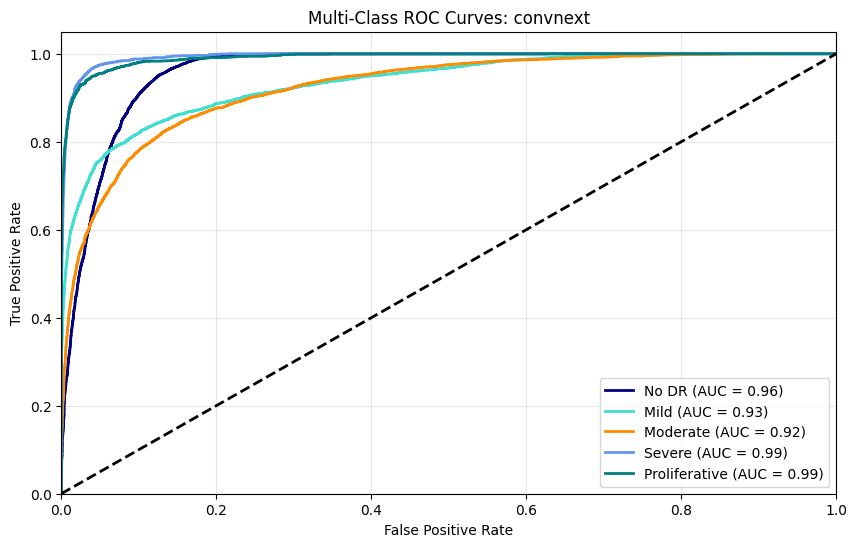

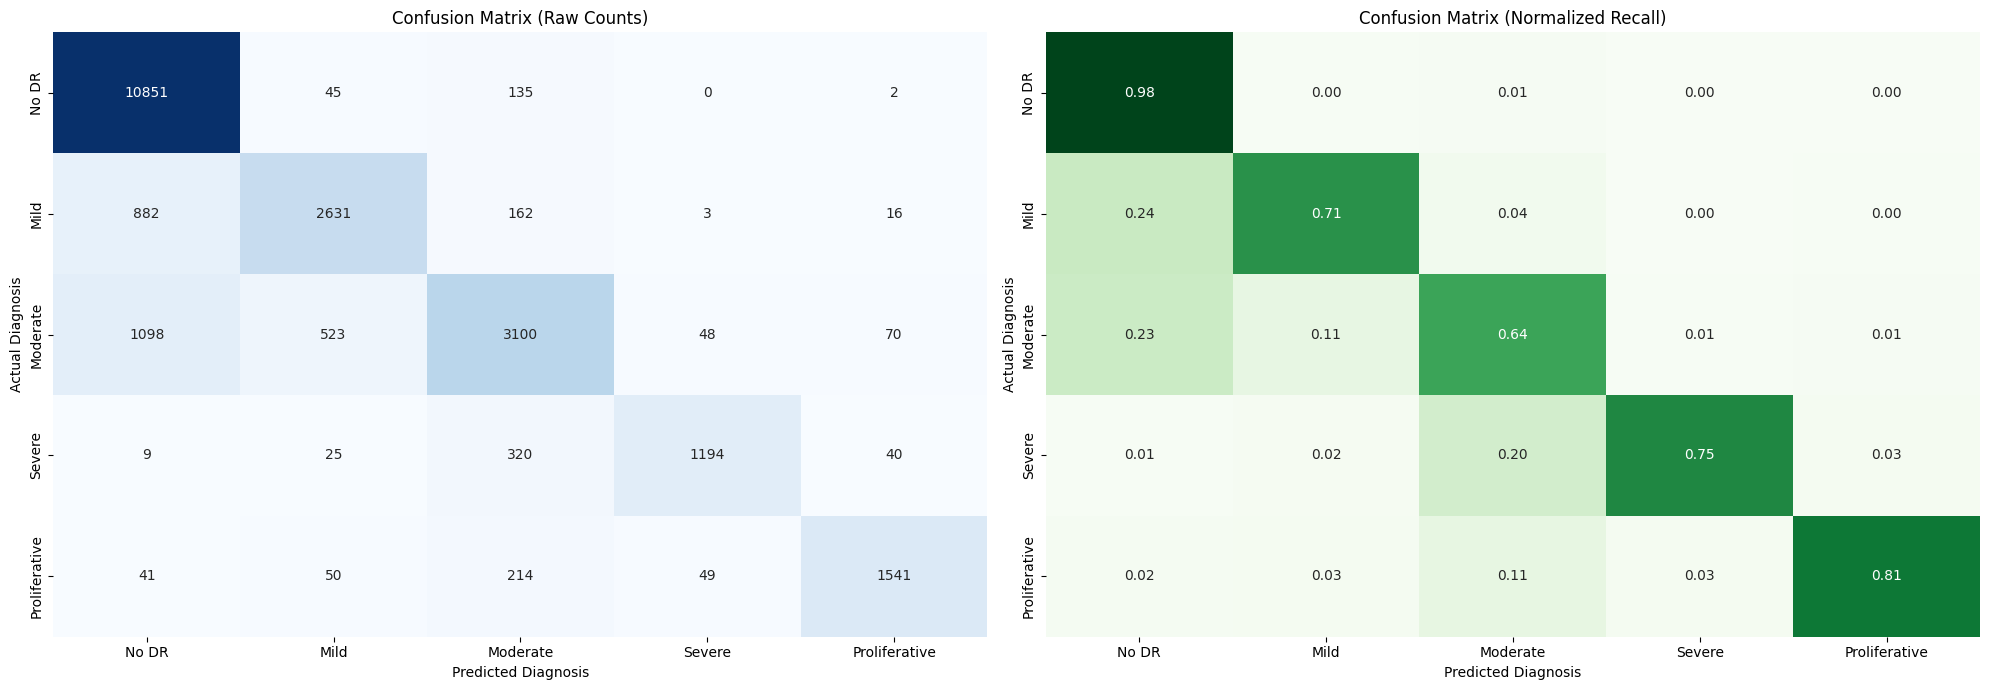


3. STATISTICAL REPORT
               precision    recall  f1-score   support

        No DR       0.84      0.98      0.91     11033
         Mild       0.80      0.71      0.76      3694
     Moderate       0.79      0.64      0.71      4839
       Severe       0.92      0.75      0.83      1588
Proliferative       0.92      0.81      0.86      1895

     accuracy                           0.84     23049
    macro avg       0.86      0.78      0.81     23049
 weighted avg       0.84      0.84      0.83     23049

[RESULT] Quadratic Weighted Kappa (QWK): 0.87452

4. VISUAL ERROR ANALYSIS (Worst Failures)
[INFO] Displaying 5 significant failure cases...


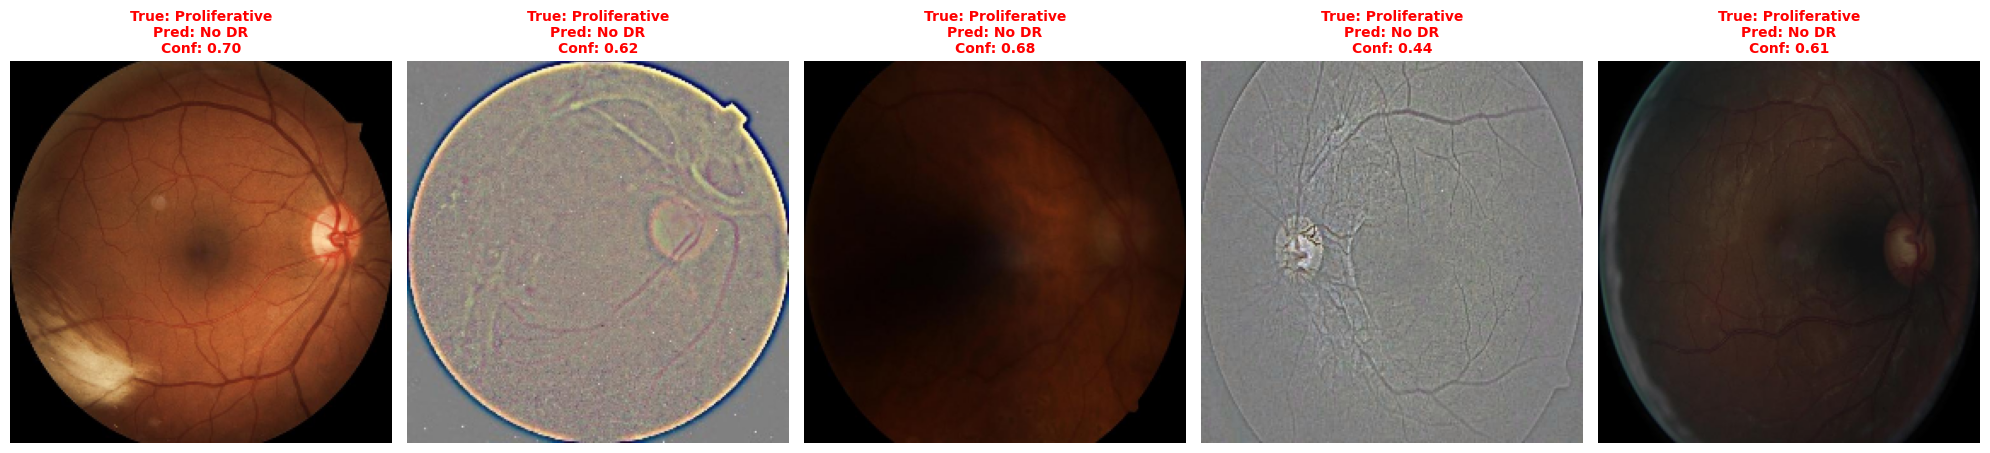

[INFO] Complete Research Evaluation Finished.


In [31]:
# ======================================================================================
# COMPLETE EVALUATION (METRICS + VISUAL ERROR ANALYSIS)
# ======================================================================================
import os
import cv2
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import cycle
from tqdm.notebook import tqdm
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report, cohen_kappa_score
from sklearn.preprocessing import label_binarize
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

# --- 1. CONFIGURATION & CLASSES (Standalone Safety) ---
class DRDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(row['image_path'])
        if img is None: 
            img = np.zeros((224, 224, 3), dtype=np.uint8)
        else: 
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Keep original for visualization if needed, but return transformed for model
        if self.transform: 
            img = self.transform(image=img)['image']
        return img, torch.tensor(row['label'], dtype=torch.long)

def run_complete_evaluation():
    print(f"[INFO] Initializing Complete Research Evaluation Protocol...")
    
    # --- A. SETUP ---
    csv_filename = "dataset_map.csv"
    if not os.path.exists(csv_filename):
        print(f"[ERROR] Split file '{csv_filename}' not found. Aborting.")
        return

    # Load Validation Data (Fold 0)
    df = pd.read_csv(csv_filename)
    valid_df = df[df['fold'] == 0].reset_index(drop=True)
    
    val_transform = A.Compose([
        A.Resize(Config.img_size, Config.img_size),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])
    
    valid_loader = DataLoader(DRDataset(valid_df, val_transform), 
                              batch_size=Config.batch_size, shuffle=False, num_workers=2)

    # Load Model
    model = DRModel(Config.model_name, num_classes=Config.num_classes).to(Config.device)
    checkpoint_path = f"{Config.model_name}_fold0_best.pth"
    
    if not os.path.exists(checkpoint_path):
        print(f"[ERROR] Weights '{checkpoint_path}' not found. Aborting.")
        return

    print(f"[INFO] Loading weights: {checkpoint_path}")
    model.load_state_dict(torch.load(checkpoint_path))
    model.eval()

    # --- B. INFERENCE LOOP ---
    print(f"[INFO] Running inference on {len(valid_df)} validation samples...")
    all_labels = []
    all_probs = []
    failed_indices = [] # Track indices where model failed
    
    with torch.no_grad():
        batch_start_idx = 0
        for images, labels in tqdm(valid_loader, desc="Inference"):
            images = images.to(Config.device)
            outputs = model(images)
            probs = outputs.softmax(dim=1).cpu().numpy()
            preds = outputs.argmax(dim=1).cpu().numpy()
            lbls = labels.numpy()
            
            all_probs.append(probs)
            all_labels.append(lbls)
            
            # Identify Failures for Visual Analysis
            batch_failures = np.where(preds != lbls)[0]
            for fail_idx in batch_failures:
                global_idx = batch_start_idx + fail_idx
                failed_indices.append({
                    'index': global_idx,
                    'true': lbls[fail_idx],
                    'pred': preds[fail_idx],
                    'prob': probs[fail_idx][preds[fail_idx]] # Confidence in wrong answer
                })
            
            batch_start_idx += len(images)

    # Consolidate Data
    y_true = np.concatenate(all_labels)
    y_probs = np.concatenate(all_probs)
    y_pred = np.argmax(y_probs, axis=1)
    class_names = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']

    # --- C. METRIC 1: ROC-AUC CURVES ---
    print("\n" + "="*80)
    print("1. ROC-AUC PERFORMANCE")
    print("="*80)
    
    y_true_bin = label_binarize(y_true, classes=[0, 1, 2, 3, 4])
    n_classes = 5
    fpr, tpr, roc_auc = dict(), dict(), dict()
    
    # Calculate & Print Scores
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        print(f"Class {i} ({class_names[i]:<12}) AUC: {roc_auc[i]:.4f}")

    # Plot
    plt.figure(figsize=(10, 6))
    colors = cycle(['navy', 'turquoise', 'darkorange', 'cornflowerblue', 'teal'])
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label='{0} (AUC = {1:0.2f})'.format(class_names[i], roc_auc[i]))
    plt.plot([0, 1], [0, 1], 'k--', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Multi-Class ROC Curves: {Config.model_name}')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

    # --- D. METRIC 2: CONFUSION MATRICES ---
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    plt.figure(figsize=(20, 7))
    
    plt.subplot(1, 2, 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix (Raw Counts)')
    plt.ylabel('Actual Diagnosis')
    plt.xlabel('Predicted Diagnosis')

    plt.subplot(1, 2, 2)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens', cbar=False,
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix (Normalized Recall)')
    plt.ylabel('Actual Diagnosis')
    plt.xlabel('Predicted Diagnosis')
    
    plt.tight_layout()
    plt.show()

    # --- E. METRIC 3: STATISTICAL REPORT ---
    print("\n" + "="*80)
    print("3. STATISTICAL REPORT")
    print("="*80)
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    qwk = cohen_kappa_score(y_true, y_pred, weights='quadratic')
    print(f"[RESULT] Quadratic Weighted Kappa (QWK): {qwk:.5f}")

    # --- F. METRIC 4: VISUAL ERROR ANALYSIS ---
    print("\n" + "="*80)
    print("4. VISUAL ERROR ANALYSIS (Worst Failures)")
    print("="*80)
    
    if len(failed_indices) == 0:
        print("[RESULT] No errors found! Model is 100% accurate on validation set.")
    else:
        # Sort failures by 'danger' (confusing Healthy with Severe is worst)
        # We prioritize showing cases where True is High (3/4) and Pred is Low (0/1)
        failed_indices.sort(key=lambda x: (x['true'] - x['pred']), reverse=True)
        
        top_failures = failed_indices[:5] # Show top 5 worst errors
        print(f"[INFO] Displaying {len(top_failures)} significant failure cases...")
        
        plt.figure(figsize=(20, 5))
        
        # Denormalization parameters (ImageNet stats)
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])

        for i, fail in enumerate(top_failures):
            # Load raw image
            row = valid_df.iloc[fail['index']]
            img = cv2.imread(row['image_path'])
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (224, 224))
            
            # Plot
            plt.subplot(1, 5, i+1)
            plt.imshow(img)
            true_txt = class_names[fail['true']]
            pred_txt = class_names[fail['pred']]
            conf = fail['prob']
            
            plt.title(f"True: {true_txt}\nPred: {pred_txt}\nConf: {conf:.2f}", 
                      color='red', fontweight='bold', fontsize=10)
            plt.axis('off')
            
        plt.tight_layout()
        plt.show()

    print("[INFO] Complete Research Evaluation Finished.")

if __name__ == "__main__":
    run_complete_evaluation()